In [114]:
from __future__ import annotations
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import norm

In [115]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: yfinance in c:\users\ayanm\anaconda3\lib\site-packages (1.2.0)



In [116]:
from datetime import date, datetime, timezone
from pathlib import Path
import yfinance as yf
from datetime import date

In [117]:
tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "TSLA", "ADBE", "CRM", "ORCL",
    "JPM", "BAC", "GS", "MS", "WFC",
    "C", "BLK", "AXP", "SCHW", "USB",
    "JNJ", "PFE", "MRK", "LLY", "ABBV",
    "TMO", "UNH", "CVS", "AMGN", "GILD",
    "KO", "PEP", "WMT", "COST", "HD",
    "MCD", "NKE", "SBUX", "TGT", "DIS",
    "XOM", "CVX", "COP", "SLB", "EOG",
    "BA", "CAT", "GE", "HON", "UPS",
    "SPY", "QQQ", "IWM", "DIA", "VTI"]

index_tickers = [
    "^GSPC", "^DJI", "^IXIC", "^NDX",
    "^RUT","^VIX", "^NYA", "^FTSE", "^GDAXI",
    "^FCHI", "^N225", "^HSI", "^STOXX50E", "^BSESN",
    "^AXJO", "^MXX", "^BVSP", "^KS11", "^TWII", "^GSPTSE" ]

In [118]:
def load_yfinance_data(
    ticker,
    start="2018-01-01",
    expiry=None
):
    """
    Download adjusted stock prices and one call-option chain.

    If expiry is not supplied, choose the nearest expiry that is
    at least seven calendar days away.
    """

    stock = yf.Ticker(ticker)

    # Adjusted historical closing prices
    close = stock.history(
        start=start,
        auto_adjust=True
    )["Close"].dropna()

    if close.empty:
        raise ValueError(f"No historical data found for {ticker}.")

    # Available option expiration dates
    expiries = list(stock.options)

    if not expiries:
        raise ValueError(f"No option data found for {ticker}.")

    today = date.today()

    # Automatically select an expiry
    if expiry is None:
        expiry = next((e for e in expiries
                if (date.fromisoformat(e) - today).days >= 30),
            expiries[0],)

    if expiry not in expiries:
        raise ValueError(f"{expiry} is not an available expiration date.")

    # Call-option data
    calls = stock.option_chain(expiry).calls

    spot = float(close.iloc[-1])

    maturity_days = (date.fromisoformat(expiry) - today).days
    maturity = max(maturity_days, 1) / 365

    return close, spot, maturity, expiry, calls

In [119]:
load_yfinance_data(
    "AMZN",
    start="2018-01-01",
    expiry=None
)

(Date
 2018-01-02 00:00:00-05:00     59.450500
 2018-01-03 00:00:00-05:00     60.209999
 2018-01-04 00:00:00-05:00     60.479500
 2018-01-05 00:00:00-05:00     61.457001
 2018-01-08 00:00:00-05:00     62.343498
                                 ...    
 2026-08-19 00:00:00-04:00    265.839996
 2026-08-20 00:00:00-04:00    260.109985
 2026-08-21 00:00:00-04:00    258.630005
 2026-08-24 00:00:00-04:00    262.070007
 2026-08-25 00:00:00-04:00    261.059998
 Name: Close, Length: 2173, dtype: float64,
 261.05999755859375,
 0.0821917808219178,
 '2026-09-25',
          contractSymbol             lastTradeDate  strike  lastPrice  bid  \
 0   AMZN260925C00155000 2026-08-20 13:53:14+00:00   155.0     109.03  0.0   
 1   AMZN260925C00170000 2026-08-21 16:28:49+00:00   170.0      89.93  0.0   
 2   AMZN260925C00180000 2026-08-25 14:43:58+00:00   180.0      81.89  0.0   
 3   AMZN260925C00200000 2026-08-21 14:29:15+00:00   200.0      60.75  0.0   
 4   AMZN260925C00205000 2026-08-24 16:48:09+00:00  

In [120]:
def load_multiple_tickers(
    tickers,
    start="2018-01-01",
    expiry=None
):
    """
    Load stock prices and call-option data for several tickers.

    When expiry=None, each ticker independently selects its
    nearest expiration date at least seven days away.
    """

    all_data = {}

    for ticker in tickers:

        close, spot, maturity, selected_expiry, calls = load_yfinance_data(
            ticker=ticker,
            start=start,
            expiry=expiry
        )

        all_data[ticker] = {
            "close": close,
            "spot": spot,
            "maturity": maturity,
            "expiry": selected_expiry,
            "calls": calls
        }

    return all_data

In [121]:
market_data = load_multiple_tickers(
    tickers=tickers,
    start="2018-01-01")

In [122]:
print(market_data["AAPL"]["spot"])
print(market_data["AAPL"]["expiry"])
print(market_data["AAPL"]["calls"].head())

309.8999938964844
2026-09-25
        contractSymbol             lastTradeDate  strike  lastPrice  bid  ask  \
0  AAPL260925C00150000 2026-08-18 14:04:26+00:00   150.0     159.75  0.0  0.0   
1  AAPL260925C00170000 2026-08-19 14:19:38+00:00   170.0     148.09  0.0  0.0   
2  AAPL260925C00190000 2026-08-10 19:55:51+00:00   190.0     118.69  0.0  0.0   
3  AAPL260925C00195000 2026-08-19 19:01:53+00:00   195.0     120.80  0.0  0.0   
4  AAPL260925C00205000 2026-08-19 19:57:48+00:00   205.0     110.85  0.0  0.0   

   change  percentChange  volume  openInterest  impliedVolatility  inTheMoney  \
0     0.0            0.0     NaN             0            0.00001        True   
1     0.0            0.0     NaN             0            0.00001        True   
2     0.0            0.0     NaN             0            0.00001        True   
3     0.0            0.0     1.0             0            0.00001        True   
4     0.0            0.0     NaN             0            0.00001        True  

In [123]:
prices = yf.download(
    tickers,
    start="2018-01-01",
    auto_adjust=True
)["Close"]

print(prices.head())

[*********************100%***********************]  55 of 55 completed


Ticker           AAPL       ABBV        ADBE        AMGN       AMZN  \
Date                                                                  
2018-01-02  40.232376  68.287079  177.699997  135.948105  59.450500   
2018-01-03  40.225365  69.355713  181.039993  138.513397  60.209999   
2018-01-04  40.412216  68.960175  183.220001  137.929672  60.479500   
2018-01-05  40.872314  70.160629  185.339996  138.751526  61.457001   
2018-01-08  40.720509  69.036514  185.039993  138.713120  62.343498   

Ticker            AXP          BA        BAC         BLK          C  ...  \
Date                                                                 ...   
2018-01-02  88.051361  282.886353  24.510147  412.035370  56.028355  ...   
2018-01-03  88.594261  283.801300  24.428173  416.382660  56.201653  ...   
2018-01-04  90.067841  282.724426  24.747871  421.879547  56.894855  ...   
2018-01-05  90.273277  294.322357  24.862635  425.473846  56.819492  ...   
2018-01-08  89.442680  295.570770  24.690489  

In [124]:
def historical_volatility(close: pd.Series, window: int = 252) -> float:
    r"""
    Estimate annualized volatility from daily log returns.

    Let r_i=log(S_i/S_{i-1}).  Under geometric Brownian motion over a daily step
    Delta=1/252,

        r_i ~ N((mu-0.5 sigma^2)Delta, sigma^2 Delta).

    For n observations, the unbiased estimator of daily variance is

        s_d^2 = (1/(n-1)) sum_i (r_i-r_bar)^2.

    Proof: write sum(r_i-r_bar)^2 = sum(r_i-m)^2-n(r_bar-m)^2.
    Taking expectations gives n sigma_d^2-sigma_d^2=(n-1)sigma_d^2.
    Variances add over independent daily increments, so annual variance is
    252*s_d^2 and annual volatility is sqrt(252)*s_d.
    """
    returns = np.log(close / close.shift(1)).dropna().tail(window)
    if len(returns) < 20:
        raise ValueError("At least 20 returns are required for a volatility estimate.")
    return float(returns.std(ddof=1) * np.sqrt(252.0))

In [125]:
def bs_price_delta(S, K, r, sigma, tau, option_type="call", q=0.0):

    "Compute Black-Scholes price and delta for a European call or put."

    if tau <= 0:
        # if time to maturity is zero or negative, then option is already at maturity

        if option_type == "call":
            price = max(S - K, 0.0)
            # intrinsic value of call at maturity

            delta = 1.0 if S > K else 0.0
            # approximate maturity delta for call

        else:
            price = max(K - S, 0.0)
            # intrinsic value of put at maturity

            delta = -1.0 if S < K else 0.0
            # approximate maturity delta for put

        return price, delta
        # return payoff and maturity delta

    d1 = (np.log(S/K) + (r-q + 0.5*sigma**2) * tau)/(sigma*np.sqrt(tau))
    # Black-Scholes d1 formula, q is dividend

    d2 = d1 - sigma * np.sqrt(tau)
    # Black-Scholes d2 formula

    if option_type == "call":
        price = S * np.exp(-q * tau) * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
        # call price formula under dividend yield q

        delta = np.exp(-q * tau) * norm.cdf(d1)
        # call delta formula

    else:
        price = K * np.exp(-r * tau) * norm.cdf(-d2) - S * np.exp(-q * tau) * norm.cdf(-d1)
        # put price formula

        delta = -np.exp(-q * tau) * norm.cdf(-d1)
    return float(price), float(delta)
    # return price and delta as plain Python floats     

In [126]:
bs_price_delta(S=305,K=290, r=0.054, sigma=0.20, tau=1/252, option_type='call', q=0.0 )

(15.062160711789488, 0.999971649153798)

In [127]:
bs_price_delta(S=200,K=220, r=0.054, sigma=0.20, tau=1/252, option_type='call', q=0.0 )[0]

7.486106494423364e-15

In [128]:
def implied_volatility(price, S, K, T, r, q):
    low=max(0.0, S*np.exp(-q*T)-K*np.exp(-r*T))
    high=S*np.exp(-q*T)
    if not np.isfinite(price) or price<low - 1e-8 or price>high + 1e-8:
        return np.nan
    objective= lambda vol: bs_price_delta(S, K, r, vol, tau=T, option_type="call", q=q)[0]-price
    try:
        return float(brentq(objective, 1e-6, 5.0, xtol=1e-10))
    except ValueError:
        return np.nan

In [129]:
def mc_price(S, K, T, r, q, sigma, paths: int=10000, seed: int=10):
    pairs=int(max(paths//2, 2))
    Z=np.random.default_rng(seed).standard_normal(size=pairs)
    S_plus=S*(np.exp((r-q-0.5*sigma**2)*T+sigma*np.sqrt(T)*Z))
    S_minus=S*(np.exp((r-q-0.5*sigma**2)*T-sigma*np.sqrt(T)*Z))
    discounted= np.exp(-r*T)*(0.5*(np.maximum(S_plus-K,0.0)+np.maximum(S_minus-K,0.0)))
    return float(discounted.mean()), float(discounted.std(ddof=1)/np.sqrt(pairs))
    

In [130]:
def historical_var_cvar(close,S,K,T,r,q, sigma, confidence: float=0.975, contracts: int=1, multipliers: int=100, window: int=500):
    if not 0.5 < confidence < 1.0:
        raise ValueError ("confidence do not lie on the favorable interval")
    shocks= np.log(close/close.shift(1)).dropna().tail(window).to_numpy(dtype=float)
    if len(shocks)<100:
        raise ValueError ("not enough historical shocks to calculate var/cvar")
    current_values= bs_price_delta(S=S, K=K, r=r, sigma=sigma, tau=T, option_type="call", q=0.0)[0]
    next_T= np.maximum(T-1.0/252.0, 0.0)
    scenario_values= np.array([bs_price_delta(S=S*np.exp(x), K=K, r=r, sigma=sigma, tau=next_T, option_type="call", q=0.0)[0] for x in shocks])
    losses= -contracts*multipliers*(scenario_values -current_values)
    var=float(np.quantile(losses, confidence, method="higher"))
    tail_count= max(int(np.ceil((1.0-confidence)* len(losses))), 1)
    cvar= float(np.mean(np.sort(losses)[-tail_count:]))
    return {"Var": var, "CVar": cvar, "scenarios": float(len(losses)), "tail_scenarios": float(tail_count)}, losses


In [36]:
#def prepare_option_chain(calls,S,T,r,q):
    #required={"strike", "ask", "bid"}
    #if not required.issubset(calls.columns):
        #raise ValueError(f"option chain lacks columns: {sorted(required- set(calls.columns))}")
    #df=calls.copy()
    #df = df[(df["bid"]>0) & (df["ask"]>= df["bid"])]
    #df = df[df["strike"].between(0.70 * S, 1.30 * S)]
    #df["market_mid"] = 0.5 * (df["bid"] + df["ask"])
    #df["spread"] = df["ask"] - df["bid"]
    #df["log_moneyness"] = np.log(df["strike"] / S)
    #df["lower_bound"] = np.maximum(0.0, S * np.exp(-q * T) - df["strike"] * np.exp(-r * T))
    #df["upper_bound"] = S * np.exp(-q * T)
    #df["bound_violation"] = (df["market_mid"] < df["lower_bound"] - 1e-8) | (df["market_mid"] > df["upper_bound"] + 1e-8)
    #df = df.sort_values("strike").reset_index(drop=True)
    #if len(df) < 5:
        #raise ValueError("Fewer than five usable bid/ask quotes; try another ticker or expiry.")
    #return df

In [131]:
def prepare_option_chain(calls, S, T, r, q):

    required = {
        "strike",
        "bid",
        "ask",
        "lastPrice"
    }

    missing = required - set(calls.columns)

    if missing:
        raise ValueError(
            f"Option chain lacks columns: {sorted(missing)}"
        )

    df = calls.copy()

    # Convert required columns to numeric values
    numeric_columns = [
        "strike",
        "bid",
        "ask",
        "lastPrice"
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

    # Remove rows without a strike
    df = df.dropna(subset=["strike"])

    # Retain strikes reasonably close to the spot price
    df = df[
        df["strike"].between(
            0.70 * S,
            1.30 * S
        )
    ].copy()

    # Identify rows with a valid bid-ask quote
    df["has_valid_bid_ask"] = (
        df["bid"].notna()
        & df["ask"].notna()
        & (df["bid"] > 0)
        & (df["ask"] >= df["bid"])
    )

    # Identify rows with a usable last traded price
    df["has_valid_last_price"] = (
        df["lastPrice"].notna()
        & (df["lastPrice"] > 0)
    )

    # Use bid-ask midpoint when available;
    # otherwise use the last traded price
    df["market_mid"] = np.where(
        df["has_valid_bid_ask"],
        0.5 * (df["bid"] + df["ask"]),
        df["lastPrice"]
    )

    df["price_source"] = np.where(
        df["has_valid_bid_ask"],
        "bid_ask_mid",
        "last_price"
    )

    # The spread is only meaningful for valid bid-ask quotes
    df["spread"] = np.where(
        df["has_valid_bid_ask"],
        df["ask"] - df["bid"],
        np.nan
    )

    # Keep rows having either a valid midpoint or last price
    df = df[
        (
            df["has_valid_bid_ask"]
            | df["has_valid_last_price"]
        )
        & df["market_mid"].notna()
        & (df["market_mid"] > 0)
    ].copy()

    # Log-moneyness
    df["log_moneyness"] = np.log(
        df["strike"] / S
    )

    # European call no-arbitrage bounds
    df["lower_bound"] = np.maximum(
        0.0,
        S * np.exp(-q*T)
        - df["strike"] * np.exp(-r*T)
    )

    df["upper_bound"] = S * np.exp(-q*T)

    df["bound_violation"] = (
        (df["market_mid"] < df["lower_bound"] - 1e-8)
        |
        (df["market_mid"] > df["upper_bound"] + 1e-8)
    )

    df = (
        df.sort_values("strike")
        .reset_index(drop=True)
    )

    print("\nOption-chain preparation")
    print("------------------------")
    print("Usable options:", len(df))
    print(
        "Bid-ask midpoint:",
        int(df["has_valid_bid_ask"].sum())
    )
    print(
        "Last-price fallback:",
        int((df["price_source"] == "last_price").sum())
    )

    if len(df) < 5:
        raise ValueError(
            "Yahoo returned fewer than five usable option prices. "
            "Select a later expiry or another ticker."
        )

    return df

In [132]:
def mathematical_sanity_tests() -> dict[str, float]:
    r"""
    Test identities whose truth does not depend on market data.

    (i) Put--call parity follows pathwise from

        (S_T-K)^+ - (K-S_T)^+ = S_T-K.

    Discount and take Q-expectations to obtain
    C-P=S e^{-qT}-K e^{-rT}.

    (ii) Central differences satisfy

        [V(S+h)-V(S-h)]/(2h) = V_S(S) + O(h^2)

    by subtracting the two third-order Taylor expansions.  Agreement with the
    closed-form delta therefore checks both price differentiation and code.

    (iii) The Monte Carlo z-score (MC-BS)/SE should usually be modest under a
    correct independent implementation.  A threshold of 4 is a reproducible
    numerical control, not a mathematical certainty; its normal-tail false
    alarm probability is roughly 6.3e-5 under the CLT.
    """
    S, K, T, r, q, sigma = 100.0, 105.0, 0.75, 0.04, 0.01, 0.25
    call = bs_price_delta(S, K, r, sigma, T, "call", q)[0]
    put = bs_price_delta(S, K, r, sigma, T, "put", q)[0]
    parity_error = abs((call - put) - (S * np.exp(-q * T) - K * np.exp(-r * T)))

    h = 1e-4 * S
    delta_fd = (bs_price_delta(S + h, K, r, sigma, T, "call", q)[0] - bs_price_delta(S - h, K, r, sigma, T, "call", q)[0]) / (2.0 * h)
    delta_error = abs(delta_fd - bs_price_delta(S, K, r, sigma, T, "call", q)[1])

    mc, se = mc_price(S, K, T, r, q, sigma, paths=100_000, seed=7)
    mc_z = (mc - call) / se
    if parity_error > 1e-10 or delta_error > 1e-7 or abs(mc_z) > 4.0:
        raise AssertionError("A mathematical implementation control failed.")
    return {"put_call_parity_error": parity_error, "delta_fd_error": delta_error, "unit_test_mc_z": mc_z}

In [133]:
def validate_market_chain(ticker: str = "AAPL", start: str = "2018-01-01",
                          expiry: str | None = None, r: float = 0.04, q: float = 0.0,
                          var_confidence: float = 0.975,
                          output_dir: str = ".") -> tuple[pd.DataFrame, pd.Series]:
    r"""
    Calibrate one parameter and validate it out of sample across strikes.

    For each clean quote M_i, solve C_BS(sigma_i;K_i)=M_i.  The quote with
    minimum |log(K_i/S)| supplies sigma_ATM.  It is the *only* calibration
    observation.  At every other strike, the validation residual is

        e_i = C_BS(sigma_ATM;K_i) - M_i.

    Reported metrics are

        bias = n^{-1} sum e_i,
        MAE  = n^{-1} sum |e_i|,
        RMSE = sqrt(n^{-1} sum e_i^2),
    quote coverage = n^{-1} sum 1{bid_i <= model_i <= ask_i}.

    Bias detects systematic direction; MAE is dollar interpretability; RMSE
    penalizes tail misses; quote coverage compares errors with executable market
    uncertainty.  A volatility smile sigma_i varying with K is direct evidence
    against the model's constant-sigma assumption.

    Finally, historical spot shocks are passed through the *same* calibrated
    model by full revaluation.  VaR/CVaR therefore quantify not only position
    risk but also the downstream consequence of the frozen-volatility modeling
    assumption documented in ``historical_var_cvar``.
    """
    controls = mathematical_sanity_tests()
    close, spot, T, chosen_expiry, raw_calls = load_yfinance_data(ticker, start, expiry)
    hist_sigma = historical_volatility(close)
    df = prepare_option_chain(raw_calls, spot, T, r, q)

    df["implied_vol"] = [
        implied_volatility(m, spot, k, T, r, q)
        for m, k in zip(df["market_mid"], df["strike"])
    ]
    valid_iv = df[np.isfinite(df["implied_vol"])].copy()
    if len(valid_iv) < 5:
        raise ValueError("Fewer than five quotes have valid implied volatilities.")
    calibration_index = (valid_iv["log_moneyness"].abs()).idxmin()
    calibration_strike = float(df.loc[calibration_index, "strike"])
    calibration_sigma = float(df.loc[calibration_index, "implied_vol"])
    df["is_calibration_quote"] = df.index == calibration_index
    df["model_price"] = [bs_price_delta(S=spot, K=float(k), r=r, sigma=calibration_sigma, tau=T, option_type="call", q=q)[0] for k in df["strike"]]
    df["pricing_error"] = df["model_price"] - df["market_mid"]
    df["absolute_error"] = df["pricing_error"].abs()
    df["error_in_spreads"] = df["absolute_error"] / df["spread"].replace(0.0, np.nan)
    df["inside_bid_ask"] =( df["has_valid_bid_ask"] & df["model_price"].between(df["bid"], df["ask"]))

    validation = df[~df["is_calibration_quote"] & np.isfinite(df["implied_vol"])].copy()
    bid_ask_validation = validation[validation["has_valid_bid_ask"]].copy()
    strikes = df["strike"].to_numpy(float)
    mids = df["market_mid"].to_numpy(float)
    slopes = np.diff(mids) / np.diff(strikes)
    monotonic_violations = int(np.sum(np.diff(mids) > 1e-8))
    convexity_violations = int(np.sum(np.diff(slopes) < -1e-8))

    mc, mc_se = mc_price(spot, calibration_strike, T, r, q, calibration_sigma)
    analytic_atm = bs_price_delta(spot, calibration_strike,  r, calibration_sigma, T, option_type = "call", q=q)[0]
    tail_risk, losses = historical_var_cvar(
        close, spot, calibration_strike, T, r, q, calibration_sigma,
        confidence=var_confidence, contracts=1, multipliers=100,
    )
    if len(bid_ask_validation) > 0:
        inside_bid_ask_pct = (100.0* bid_ask_validation["inside_bid_ask"].mean())

        median_error_in_spreads = (bid_ask_validation["error_in_spreads"].median())

    else:
        inside_bid_ask_pct = np.nan
        median_error_in_spreads = np.nan
    summary = pd.Series({
        "ticker": ticker.upper(),
        "valuation_date_utc": datetime.now(timezone.utc).date().isoformat(),
        "expiry": chosen_expiry,
        "spot": spot,
        "maturity_years": T,
        "risk_free_rate": r,
        "dividend_yield": q,
        "historical_vol_252d": hist_sigma,
        "calibration_strike": calibration_strike,
        "calibrated_atm_vol": calibration_sigma,
        "validation_quotes": len(validation),
        "bias": validation["pricing_error"].mean(),
        "mae": validation["absolute_error"].mean(),
        "rmse": np.sqrt(np.mean(validation["pricing_error"] ** 2)),
        "inside_bid_ask_pct": 100.0 * validation["inside_bid_ask"].mean(),
        "median_error_in_spreads": validation["error_in_spreads"].median(),
        "bound_violations": int(df["bound_violation"].sum()),
        "monotonicity_violations": monotonic_violations,
        "convexity_violations": convexity_violations,
        "inside_bid_ask_pct": inside_bid_ask_pct,
        "median_error_in_spreads": median_error_in_spreads,
        "mc_price_atm": mc,
        "analytic_price_atm": analytic_atm,
        "mc_standard_error": mc_se,
        "market_mc_z": (mc - analytic_atm) / mc_se,
        "var_confidence": var_confidence,
        "position_long_call_contracts": 1,
        "contract_multiplier": 100,
        "one_day_var_usd": tail_risk["Var"],
        "one_day_cvar_usd": tail_risk["CVar"],
        "var_scenarios": int(tail_risk["scenarios"]),
        "cvar_tail_scenarios": int(tail_risk["tail_scenarios"]),
        **controls,
    })

    output = Path(output_dir)
    output.mkdir(parents=True, exist_ok=True)
    prefix = output / f"{ticker.lower()}_option"
    df.to_csv(f"{prefix}_validation.csv", index=False)
    summary.rename("value").to_csv(f"{prefix}_summary.csv", header=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    axes[0].plot(df["strike"], df["market_mid"], "o", label="Market mid", ms=4)
    axes[0].plot(df["strike"], df["model_price"], "-", label="BS: one ATM vol")
    axes[0].fill_between(df["strike"], df["bid"], df["ask"], alpha=0.18, label="Bid--ask")
    axes[0].axvline(calibration_strike, color="grey", ls="--", lw=1, label="Calibration strike")
    axes[0].set(xlabel="Strike", ylabel="Call price", title=f"{ticker.upper()} {chosen_expiry}: market vs model")
    axes[0].legend(fontsize=8)

    axes[1].plot(valid_iv["log_moneyness"], 100.0 * valid_iv["implied_vol"], "o-")
    axes[1].axhline(100.0 * calibration_sigma, color="grey", ls="--", lw=1)
    axes[1].set(xlabel="log(K/S)", ylabel="Implied volatility (%)", title="Smile = constant-vol model risk")

    axes[2].hist(losses, bins=30, alpha=0.75, edgecolor="white")
    axes[2].axvline(tail_risk["Var"], color="darkorange", lw=2,
                    label=f"VaR {100 * var_confidence:.1f}%")
    axes[2].axvline(tail_risk["CVar"], color="darkred", lw=2, ls="--",
                    label="CVaR / ES")
    axes[2].set(xlabel="One-day loss (USD)", ylabel="Historical scenarios",
                title="1 long call: full revaluation")
    axes[2].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(f"{prefix}_validation.png", dpi=160)
    plt.show()
    plt.close(fig)

    print("\nEQUITY OPTION MODEL VALIDATION SUMMARY")
    print(summary.to_string())
    print(f"\nSaved: {prefix}_validation.csv, {prefix}_summary.csv, {prefix}_validation.png")
    return df, summary


#if __name__ == "__main__":
    # Edit only these plain inputs; no parameter class or configuration framework.
    #validate_market_chain(
        #ticker="AAPL",
        #start="2018-01-01",
        #expiry=None,       # None chooses the nearest expiry at least 7 days away.
        #r=0.04,            # Replace with the maturity-matched continuously compounded rate.
        #q=0.00,            # Replace with a dividend/borrow assumption when appropriate.
        #var_confidence=0.975,
        #output_dir=".",
    #)


Option-chain preparation
------------------------
Usable options: 28
Bid-ask midpoint: 0
Last-price fallback: 28


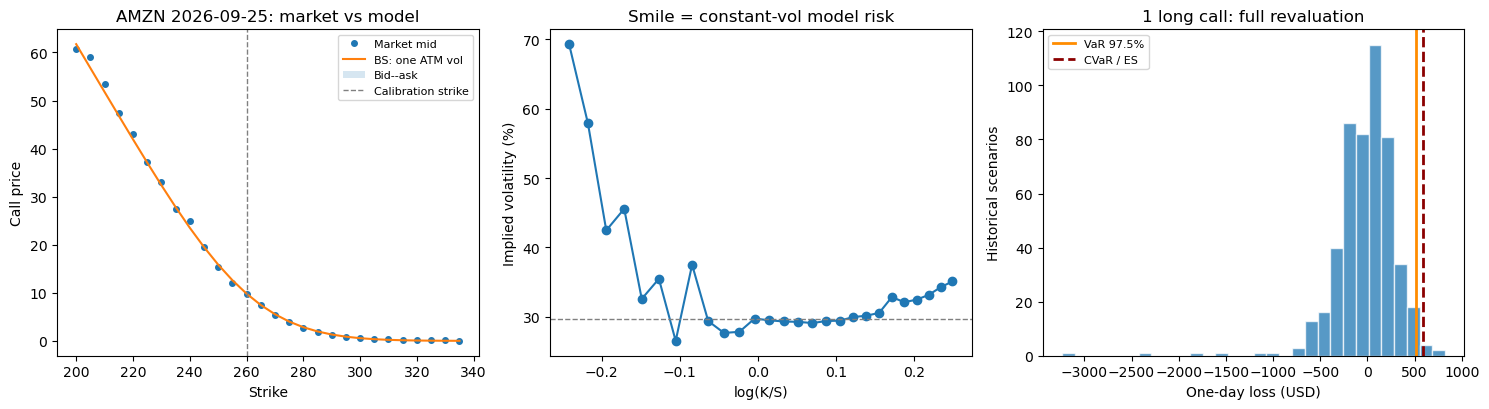


EQUITY OPTION MODEL VALIDATION SUMMARY
ticker                                AMZN
valuation_date_utc              2026-08-26
expiry                          2026-09-25
spot                            261.059998
maturity_years                    0.082192
risk_free_rate                        0.04
dividend_yield                         0.0
historical_vol_252d               0.337651
calibration_strike                   260.0
calibrated_atm_vol                0.297258
validation_quotes                       26
bias                             -0.252633
mae                               0.411246
rmse                              0.716576
inside_bid_ask_pct                     NaN
median_error_in_spreads                NaN
bound_violations                         1
monotonicity_violations                  0
convexity_violations                     7
mc_price_atm                      9.716162
analytic_price_atm                    9.83
mc_standard_error                 0.104633
market_mc_z   

In [134]:
if __name__ == "__main__":
    # Edit only these plain inputs; no parameter class or configuration framework.
    validate_market_chain(
        ticker="AMZN",
        start="2018-01-01",
        expiry=None,       # None chooses the nearest expiry at least 7 days away.
        r=0.04,            # Replace with the maturity-matched continuously compounded rate.
        q=0.00,            # Replace with a dividend/borrow assumption when appropriate.
        var_confidence=0.975,
        output_dir=".",
    )


Option-chain preparation
------------------------
Usable options: 58
Bid-ask midpoint: 0
Last-price fallback: 58


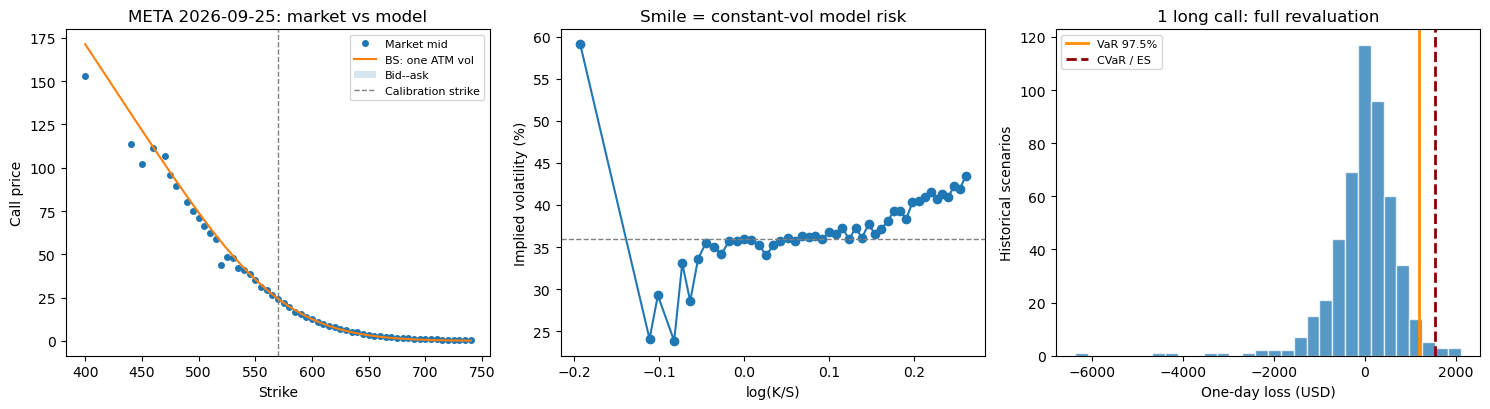


EQUITY OPTION MODEL VALIDATION SUMMARY
ticker                                 META
valuation_date_utc               2026-08-26
expiry                           2026-09-25
spot                             570.049988
maturity_years                     0.082192
risk_free_rate                         0.04
dividend_yield                          0.0
historical_vol_252d                0.388162
calibration_strike                    570.0
calibrated_atm_vol                 0.360085
validation_quotes                        46
bias                                0.14811
mae                                0.777093
rmse                               1.337108
inside_bid_ask_pct                      NaN
median_error_in_spreads                 NaN
bound_violations                         11
monotonicity_violations                   6
convexity_violations                     29
mc_price_atm                      24.094333
analytic_price_atm                     24.4
mc_standard_error                  0

In [135]:
if __name__ == "__main__":
    # Edit only these plain inputs; no parameter class or configuration framework.
    validate_market_chain(
        ticker="META",
        start="2018-01-01",
        expiry=None,       # None chooses the nearest expiry at least 7 days away.
        r=0.04,            # Replace with the maturity-matched continuously compounded rate.
        q=0.00,            # Replace with a dividend/borrow assumption when appropriate.
        var_confidence=0.975,
        output_dir=".",
    )


Option-chain preparation
------------------------
Usable options: 37
Bid-ask midpoint: 0
Last-price fallback: 37


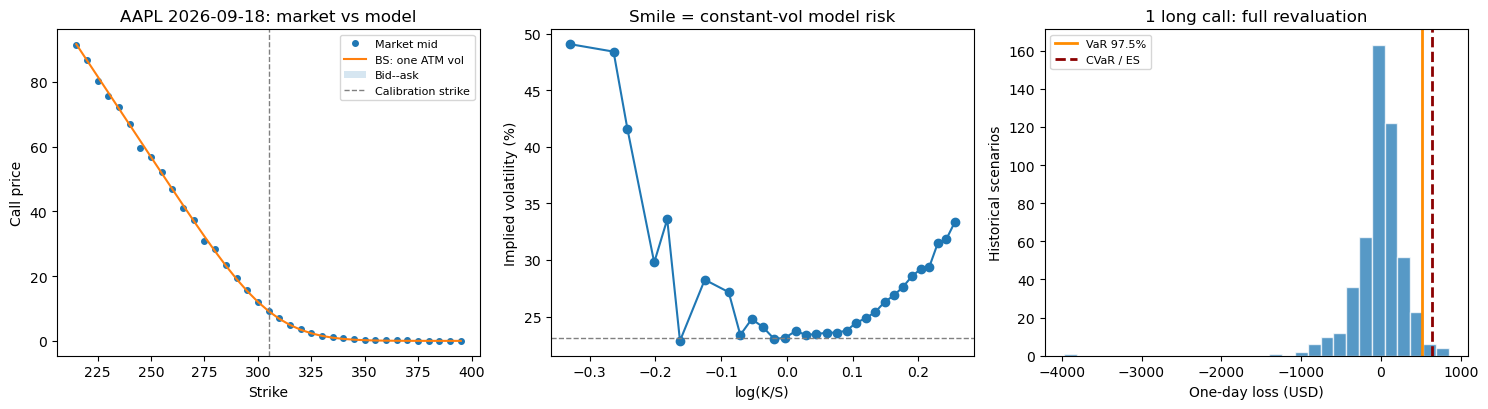


EQUITY OPTION MODEL VALIDATION SUMMARY
ticker                                AAPL
valuation_date_utc              2026-08-18
expiry                          2026-09-18
spot                            305.929993
maturity_years                    0.084932
risk_free_rate                        0.04
dividend_yield                         0.0
historical_vol_252d               0.250024
calibration_strike                   305.0
calibrated_atm_vol                0.231055
validation_quotes                       30
bias                             -0.164048
mae                               0.165984
rmse                              0.216777
inside_bid_ask_pct                     NaN
median_error_in_spreads                NaN
bound_violations                         6
monotonicity_violations                  1
convexity_violations                    10
mc_price_atm                      9.106428
analytic_price_atm                    9.21
mc_standard_error                 0.094898
market_mc_z   

In [102]:
if __name__ == "__main__":
    # Edit only these plain inputs; no parameter class or configuration framework.
    validate_market_chain(
        ticker="AAPL",
        start="2018-01-01",
        expiry=None,       # None chooses the nearest expiry at least 7 days away.
        r=0.04,            # Replace with the maturity-matched continuously compounded rate.
        q=0.00,            # Replace with a dividend/borrow assumption when appropriate.
        var_confidence=0.975,
        output_dir=".",
    )


Option-chain preparation
------------------------
Usable options: 34
Bid-ask midpoint: 0
Last-price fallback: 34


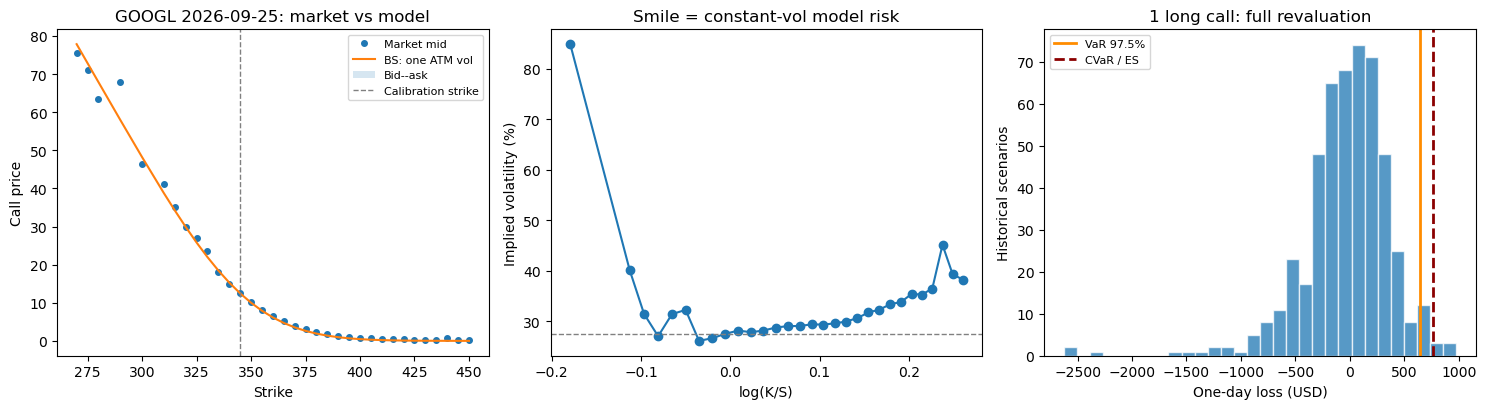


EQUITY OPTION MODEL VALIDATION SUMMARY
ticker                               GOOGL
valuation_date_utc              2026-08-26
expiry                          2026-09-25
spot                            346.959991
maturity_years                    0.082192
risk_free_rate                        0.04
dividend_yield                         0.0
historical_vol_252d               0.322686
calibration_strike                   345.0
calibrated_atm_vol                0.275065
validation_quotes                       29
bias                             -0.740241
mae                               0.802176
rmse                              1.957889
inside_bid_ask_pct                     NaN
median_error_in_spreads                NaN
bound_violations                         4
monotonicity_violations                  2
convexity_violations                    10
mc_price_atm                     12.342776
analytic_price_atm                   12.48
mc_standard_error                 0.127449
market_mc_z   

In [136]:
if __name__ == "__main__":
    # Edit only these plain inputs; no parameter class or configuration framework.
    validate_market_chain(
        ticker="GOOGL",
        start="2018-01-01",
        expiry=None,       # None chooses the nearest expiry at least 7 days away.
        r=0.04,            # Replace with the maturity-matched continuously compounded rate.
        q=0.00,            # Replace with a dividend/borrow assumption when appropriate.
        var_confidence=0.975,
        output_dir=".",
    )


Option-chain preparation
------------------------
Usable options: 26
Bid-ask midpoint: 0
Last-price fallback: 26


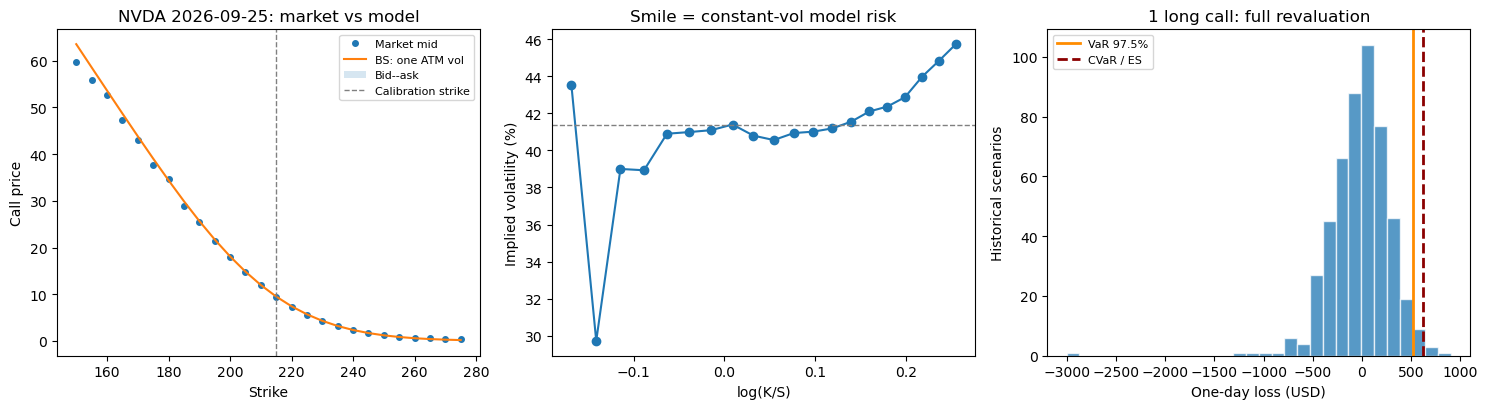


EQUITY OPTION MODEL VALIDATION SUMMARY
ticker                                NVDA
valuation_date_utc              2026-08-26
expiry                          2026-09-25
spot                            213.050003
maturity_years                    0.082192
risk_free_rate                        0.04
dividend_yield                         0.0
historical_vol_252d               0.367707
calibration_strike                   215.0
calibrated_atm_vol                0.413936
validation_quotes                       19
bias                              0.082528
mae                                0.18058
rmse                              0.273722
inside_bid_ask_pct                     NaN
median_error_in_spreads                NaN
bound_violations                         6
monotonicity_violations                  0
convexity_violations                     4
mc_price_atm                      9.373736
analytic_price_atm                     9.5
mc_standard_error                 0.122334
market_mc_z   

In [137]:
if __name__ == "__main__":
    # Edit only these plain inputs; no parameter class or configuration framework.
    validate_market_chain(
        ticker="NVDA",
        start="2018-01-01",
        expiry=None,       # None chooses the nearest expiry at least 7 days away.
        r=0.04,            # Replace with the maturity-matched continuously compounded rate.
        q=0.00,            # Replace with a dividend/borrow assumption when appropriate.
        var_confidence=0.975,
        output_dir=".",
    )


Option-chain preparation
------------------------
Usable options: 41
Bid-ask midpoint: 0
Last-price fallback: 41


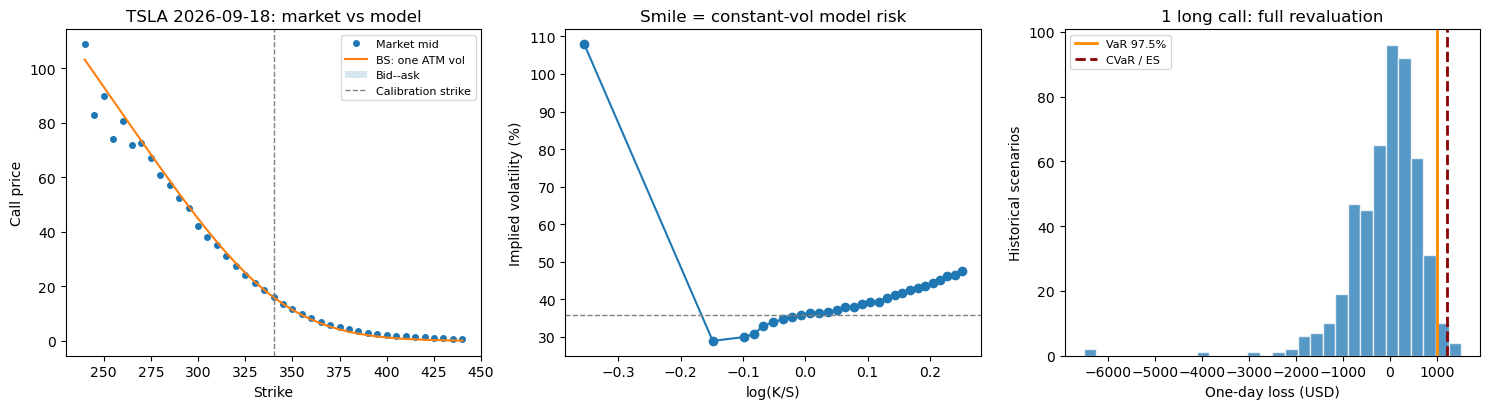


EQUITY OPTION MODEL VALIDATION SUMMARY
ticker                                 TSLA
valuation_date_utc               2026-08-18
expiry                           2026-09-18
spot                             342.269989
maturity_years                     0.084932
risk_free_rate                         0.04
dividend_yield                          0.0
historical_vol_252d                0.466262
calibration_strike                    340.0
calibrated_atm_vol                 0.359381
validation_quotes                        28
bias                              -0.527306
mae                                0.925009
rmse                               1.330833
inside_bid_ask_pct                      NaN
median_error_in_spreads                 NaN
bound_violations                         12
monotonicity_violations                   3
convexity_violations                      9
mc_price_atm                        15.8151
analytic_price_atm                     16.0
mc_standard_error                  0

In [105]:
if __name__ == "__main__":
    # Edit only these plain inputs; no parameter class or configuration framework.
    validate_market_chain(
        ticker="TSLA",
        start="2018-01-01",
        expiry=None,       # None chooses the nearest expiry at least 7 days away.
        r=0.04,            # Replace with the maturity-matched continuously compounded rate.
        q=0.00,            # Replace with a dividend/borrow assumption when appropriate.
        var_confidence=0.975,
        output_dir=".",
    )